In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

## Configuration

`IN_DIR` is where `explain_attention.py` wrote its output. The relative paths
below assume this runs from `Disease_classification_loo/`; add one `../` per
extra level if the notebook sits deeper.

In [3]:
IN_DIR = "Data/biomark"
OUT_DIR = IN_DIR

# The old notebook used social_niche_embedding_100.txt. The models, though,
# were trained on the removing_disease_samples version (GLOVE_DEFAULT in
# run_attention_biom_with_SNEs.py). If the figure is about the space the model
# actually used, switch to the commented line.
SNE_PATH = "../../data/social_niche_embedding_removing_disease_samples_100.txt"
# SNE_PATH = "../../data/social_niche_embedding_removing_disease_samples_100.txt"
PHYLO_PATH = "../../data/phylo_embed_PCA_100.txt"

TOP_N = 50        # markers taken from each end of the ranking
POOL = "sample"   # "sample": the old notebook's weighting, by sample count
                  # "fold":   every cohort counts once
N_PERM = 999      # label shuffles behind the silhouette p-value
SEED = 42

In [4]:
def load_embedding(path, name):
    emb = pd.read_csv(path, header=None, sep=" ", low_memory=False, index_col=0)
    # '<unk>' is the vocabulary's catch-all, not a taxon, and it would sit in
    # the middle of any distance matrix it entered.
    for marker in ("<unk>", "<pad>"):
        if marker in emb.index:
            emb = emb.drop(marker)
    emb = emb[~emb.index.duplicated(keep="first")]
    print(f"{name}: {emb.shape[0]} taxa x {emb.shape[1]} dims")
    return emb


sne = load_embedding(SNE_PATH, "SNE")
phylo = load_embedding(PHYLO_PATH, "Phylo")

# Only taxa both spaces cover can be placed in both, and the figure compares
# the two spaces on one set of markers.
taxa = np.intersect1d(sne.index.values, phylo.index.values)
print(f"taxa in both embeddings: {len(taxa)}")

SNE: 14093 taxa x 100 dims
Phylo: 14093 taxa x 100 dims
taxa in both embeddings: 14093


## Reading the attributions

In [4]:
def fold_table(task, source):
    """fold -> disease, from the summary the explainer wrote.

    Read rather than reconstructed from file names: a fold is named like
    CRC_PRJEB6070 and study IDs contain underscores of their own, so splitting
    the name back into disease and study is not reliable.
    """
    prefix = "attn" if source == "attn" else "shap"
    path = os.path.join(IN_DIR, f"{prefix}_summary_{task}.csv")
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"{path} not found; run explain_attention.py --task {task} first")
    s = pd.read_csv(path, usecols=["fold", "disease"]).drop_duplicates()
    return s.set_index("fold")["disease"].to_dict()

In [5]:
def grad_importance(task, folds):
    """Signed attribution per taxon, per disease, from the per-fold matrices.

    Returns {disease: (sample_weighted, fold_weighted)}.

    Taxa a cohort's table does not carry are zero-filled rather than dropped,
    as in the old notebook: a taxon that cohort never observed contributed
    nothing to its predictions, which is a value, not a gap.
    """
    out = {}
    for disease in sorted(set(folds.values())):
        rows, per_fold = [], []
        for fold, d in folds.items():
            if d != disease:
                continue
            path = os.path.join(IN_DIR, f"shap_grad_{task}_{fold}.csv")
            if not os.path.isfile(path):
                print(f"  [skip] {path} not found")
                continue
            df = pd.read_csv(path, index_col=0).reindex(columns=taxa,
                                                        fill_value=0.0)
            rows.append(df)
            per_fold.append(df.mean(axis=0))
            print(f"  {disease}/{fold}: {df.shape[0]} samples, "
                  f"{int((df != 0).any(axis=0).sum())} taxa with a non-zero "
                  f"attribution")
        if rows:
            out[disease] = (pd.concat(rows).mean(axis=0),
                            pd.concat(per_fold, axis=1).mean(axis=1))
    return out

In [6]:
def attn_importance(task, folds):
    """Case-minus-control attention differential per taxon, per disease.

    Attention has no sign to read a direction off: it is a distribution over
    the taxa a sample carries and is never negative. Its *level* is also
    largely abundance, since the attention scores scale with abundance
    squared. The differential is what has a direction, and what the abundance
    mostly cancels out of. explain_attention.py computed it per fold; this
    only aggregates over the cohorts of a disease.
    """
    s = pd.read_csv(os.path.join(IN_DIR, f"attn_summary_{task}.csv"))
    out = {}
    for disease, part in s.groupby("disease"):
        wide = part.pivot_table(index="otu", columns="fold",
                                values="case_minus_control")
        mean = wide.mean(axis=1).reindex(taxa).fillna(0.0)
        print(f"  {disease}: {wide.shape[1]} cohort(s), {wide.shape[0]} taxa")
        # Nothing sample-level to pool here, so both weightings are the same.
        out[disease] = (mean, mean)
    return out

## Markers, MDS, separation

In [7]:
def markers(importance, n=TOP_N):
    """The n most negative and the n most positive taxa.

    Taxa at exactly 0 are dropped first: no sample carries them, their
    attribution is exactly zero, and they belong in the middle of the ranking
    -- but a tie at 0 reaches its ends when there are few non-zero taxa.
    """
    s = importance[importance != 0].sort_values()
    return list(s.index[:n]), list(s.index[-n:])


def _mds(D):
    """normalized_stress predates sklearn 1.2; passing the current default
    there is an error and its absence is the same behaviour. Passed at all
    only to silence the FutureWarning."""
    try:
        m = MDS(n_components=2, dissimilarity="precomputed",
                random_state=SEED, normalized_stress=False)
        return m, m.fit_transform(D)
    except TypeError:
        m = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED)
        return m, m.fit_transform(D)


def mds_frame(emb, ctrl, dis, disease, emb_type):
    ids = list(ctrl) + list(dis)
    # A vector's cosine with itself comes back as 1 +/- 1e-16, so the diagonal
    # of 1 - cos lands just either side of zero. MDS tolerates that; the
    # silhouette refuses a distance matrix with a negative in it, and it is
    # right to. Pinned rather than nudged: the diagonal of a distance matrix
    # is 0 by definition, not by arithmetic.
    D = np.clip(1 - cosine_similarity(emb.loc[ids]), 0, None)
    np.fill_diagonal(D, 0.0)
    mds, xy = _mds(D)
    frame = pd.DataFrame({
        "t_SNE_1": xy[:, 0], "t_SNE_2": xy[:, 1],
        "group": [disease if i in set(dis) else "Ctrl" for i in ids],
        "emb_type": emb_type, "fid": ids})
    return frame, D, mds.stress_


def separation(D, ids, dis, n_perm=N_PERM):
    """The figure's claim as a number: do the two marker sets separate here.

    Computed on the cosine distances themselves rather than on the two MDS
    coordinates. MDS is fitted to those distances and its stress is where the
    information was lost, so scoring the projection scores the projection.
    """
    y = np.array([1 if i in set(dis) else 0 for i in ids])
    obs = float(silhouette_score(D, y, metric="precomputed"))
    rng = np.random.default_rng(SEED)
    null = np.array([silhouette_score(D, rng.permutation(y),
                                      metric="precomputed")
                     for _ in range(n_perm)])
    return obs, float((np.sum(null >= obs) + 1) / (n_perm + 1))

In [8]:
def analyse(task, source, top_n=TOP_N, pool=POOL, write=True):
    """One (task, attribution source) pair: marker list and separation table."""
    folds = fold_table(task, source)
    print(f"=== {task} / {source}: {len(folds)} fold(s), "
          f"{len(set(folds.values()))} disease(s) ===")
    imp = (attn_importance(task, folds) if source == "attn"
           else grad_importance(task, folds))

    marker_rows, sep_rows = [], []
    for disease, (pooled, by_fold) in sorted(imp.items()):
        chosen = pooled if pool == "sample" else by_fold
        ctrl, dis = markers(chosen, top_n)

        # The old notebook pooled every sample of every cohort into one mean,
        # which weights a cohort by its sample count. With --max-samples
        # capping the large cohorts that weighting is no longer the old one
        # either, so both are computed and their marker lists compared. If
        # they disagree, pool="fold" is the defensible one.
        o_ctrl, o_dis = markers(pooled, top_n)
        f_ctrl, f_dis = markers(by_fold, top_n)
        print(f"  [pool] {disease}: sample- vs fold-weighted markers overlap "
              f"{len(set(o_ctrl) & set(f_ctrl))}/{top_n} (control) "
              f"{len(set(o_dis) & set(f_dis))}/{top_n} (disease)")

        marker_rows.append(pd.DataFrame({
            "task": task, "source": source, "disease": disease,
            "fid": ctrl + dis,
            "group": ["Ctrl"] * len(ctrl) + [disease] * len(dis),
            "importance": list(chosen[ctrl]) + list(chosen[dis]),
            "importance_sample_pooled": list(pooled[ctrl]) + list(pooled[dis]),
            "importance_fold_pooled": list(by_fold[ctrl]) + list(by_fold[dis])}))

        frames = []
        for emb, emb_type in ((phylo, "Phylo"), (sne, "SNE")):
            frame, D, stress = mds_frame(emb, ctrl, dis, disease, emb_type)
            sil, p = separation(D, list(ctrl) + list(dis), dis)
            frames.append(frame)
            sep_rows.append(dict(task=task, source=source, disease=disease,
                                 emb_type=emb_type, silhouette=sil,
                                 p_shuffle=p, mds_stress=stress,
                                 n_markers=len(ctrl) + len(dis)))
            print(f"  [mds ] {disease} {emb_type:<5} silhouette {sil:+.4f} "
                  f"p={p:.3f}  stress {stress:.1f}")
        if write:
            path = os.path.join(OUT_DIR, f"MDS_{task}_{disease}_{source}.csv")
            pd.concat(frames).to_csv(path)
            print(f"  [out ] {path}")

    markers_df = pd.concat(marker_rows, ignore_index=True)
    sep_df = pd.DataFrame(sep_rows)
    if write:
        markers_df.to_csv(
            os.path.join(OUT_DIR, f"biomarkers_{task}_{source}.csv"), index=False)
        sep_df.to_csv(
            os.path.join(OUT_DIR, f"separation_{task}_{source}.csv"), index=False)
    return markers_df, sep_df

## disease task (CRC + IBD), integrated gradients

The two sections of the old notebook. The `MDS_disease_{disease}_grad.csv`
files carry exactly the old columns -- `t_SNE_1, t_SNE_2, group, emb_type,
fid` -- so any existing plotting code reads them unchanged.

In [9]:
markers_dis, sep_dis = analyse("disease", "grad")

=== disease / grad: 15 fold(s), 2 disease(s) ===
  CRC/CRC_PRJDB11845: 102 samples, 543 taxa with a non-zero attribution
  CRC/CRC_PRJEB36789: 153 samples, 1345 taxa with a non-zero attribution
  CRC/CRC_PRJEB6070: 91 samples, 1266 taxa with a non-zero attribution
  CRC/CRC_PRJNA290926: 255 samples, 1310 taxa with a non-zero attribution
  CRC/CRC_PRJNA318004: 228 samples, 1151 taxa with a non-zero attribution
  CRC/CRC_PRJNA430990: 146 samples, 886 taxa with a non-zero attribution
  CRC/CRC_PRJNA824020: 59 samples, 477 taxa with a non-zero attribution
  IBD/IBD_PRJNA324147: 88 samples, 995 taxa with a non-zero attribution
  IBD/IBD_PRJNA368966: 64 samples, 1019 taxa with a non-zero attribution
  IBD/IBD_PRJNA422193: 107 samples, 1394 taxa with a non-zero attribution
  IBD/IBD_PRJNA431126: 300 samples, 1565 taxa with a non-zero attribution
  IBD/IBD_PRJNA450340: 127 samples, 1310 taxa with a non-zero attribution
  IBD/IBD_RISK_PRISM_f: 300 samples, 1516 taxa with a non-zero attribution


In [10]:
sep_dis

,task,source,disease,emb_type,silhouette,p_shuffle,mds_stress,n_markers
0,disease,grad,CRC,Phylo,0.026346,0.001,739.746383,100
1,disease,grad,CRC,SNE,0.132961,0.001,247.618639,100
2,disease,grad,IBD,Phylo,-0.000212,0.476,703.082461,100
3,disease,grad,IBD,SNE,0.170539,0.001,169.333075,100


In [11]:
# CRC control-associated markers: the strongest of the 50 pushing towards health
markers_dis.query("disease == 'CRC' and group == 'Ctrl'").head(10)

,task,source,disease,fid,group,importance,importance_sample_pooled,importance_fold_pooled
0,disease,grad,CRC,FJ362935.1.1246,Ctrl,-0.006300,-0.006300,-0.006529
1,disease,grad,CRC,FJ365305.1.1340,Ctrl,-0.005657,-0.005657,-0.006264
2,disease,grad,CRC,DQ807131.1.1283,Ctrl,-0.005437,-0.005437,-0.003574
3,disease,grad,CRC,DQ803441.1.1240,Ctrl,-0.005084,-0.005084,-0.004709
4,disease,grad,CRC,FJ371314.1.1260,Ctrl,-0.004527,-0.004527,-0.004386
5,disease,grad,CRC,FJ366783.1.1350,Ctrl,-0.004472,-0.004472,-0.006476
6,disease,grad,CRC,GQ492466.1.1344,Ctrl,-0.004228,-0.004228,-0.004214
7,disease,grad,CRC,FJ371179.1.1259,Ctrl,-0.003904,-0.003904,-0.004116
8,disease,grad,CRC,FJ371191.1.1358,Ctrl,-0.003614,-0.003614,-0.005122
9,disease,grad,CRC,DQ803925.1.1280,Ctrl,-0.003596,-0.003596,-0.003459


In [12]:
# CRC disease-associated markers
markers_dis.query("disease == 'CRC' and group == 'CRC'").tail(10)

,task,source,disease,fid,group,importance,importance_sample_pooled,importance_fold_pooled
90,disease,grad,CRC,FJ507231.1.1307,CRC,0.005823,0.005823,0.008429
91,disease,grad,CRC,JQ467142.1.1299,CRC,0.005827,0.005827,0.006427
92,disease,grad,CRC,KY983579.1.1217,CRC,0.005995,0.005995,0.006066
93,disease,grad,CRC,JQ449887.1.1241,CRC,0.006088,0.006088,0.005913
94,disease,grad,CRC,FJ371434.1.1338,CRC,0.007649,0.007649,0.011076
95,disease,grad,CRC,EU762506.1.1327,CRC,0.007668,0.007668,0.010362
96,disease,grad,CRC,GQ491160.1.1334,CRC,0.008537,0.008537,0.008767
97,disease,grad,CRC,JQ467804.1.1375,CRC,0.009018,0.009018,0.011204
98,disease,grad,CRC,FJ557734.1.1287,CRC,0.009116,0.009116,0.010258
99,disease,grad,CRC,JQ455437.1.1278,CRC,0.009723,0.009723,0.010717


## Plots

Each panel carries a **PERMANOVA** (Anderson 2001), the test normally put on a
microbiome ordination. It asks whether the distances *between* the two marker
groups exceed the distances *within* them by more than a random relabelling
would give:

    SS_total   = sum of all squared distances / n
    SS_within  = the same summed inside each group, over that group's size
    pseudo-F   = (SS_between / (a - 1)) / (SS_within / (n - a))
    R2         = SS_between / SS_total

`p` is the fraction of `N_PERM` random relabellings reaching that pseudo-F,
`(hits + 1) / (N_PERM + 1)`. Nothing is assumed about normality or equal
variances -- the null distribution is generated by shuffling -- which is why
`p = 0.001` is the floor with `N_PERM = 999` rather than a smaller number.

Two things the annotation deliberately does **not** say:

* It is computed on the **cosine distances**, not on the two MDS coordinates
  drawn in the panel. MDS is fitted to those distances and the stress reported
  in `sep_*` is exactly what it could not preserve -- large here, and much
  larger for Phylo than for SNE -- so a test on the picture would be a test of
  the picture. The panel is an illustration; the statistic is about the full
  embedding space.
* `R2` is the share of variation the grouping explains, and it is small even
  where `p` is 0.001. A separation can be highly reproducible and still
  account for a few percent of the spread; the p-value speaks to the first and
  `R2` to the second, and only reporting both is honest.

One caveat that belongs next to this figure in the manuscript. The models'
taxon embeddings are the SNE vectors, frozen -- for the lodo models, trained
with `--no-linear-branch`, an SNE vector is the *only* thing the network knows
about a taxon. Taxa the model pushes the same way must therefore have similar
SNE vectors to some degree, so part of the separation seen in the SNE panel is
built in. What the comparison shows is that the SNE space carries the
disease-relevant structure the model can exploit and the phylogenetic space
does not; it is not an independent validation of SNE by the model's output.

In [39]:
EMB = {"Phylo": phylo, "SNE": sne}
GROUP_COLORS = ("#00BFC4", "#F8766D")   # control, disease


def permanova(D, y, n_perm=N_PERM, seed=SEED):
    """PERMANOVA (Anderson 2001) on a precomputed distance matrix.

    Returns pseudo-F, R2 and a permutation p-value. See the markdown above for
    what each one is; the short version is that it compares between-group to
    within-group distances and calibrates the comparison by shuffling the
    labels, so no distributional assumption enters.
    """
    D2 = np.asarray(D, dtype=float) ** 2
    y = np.asarray(y)
    n = len(y)
    groups = np.unique(y)
    a = len(groups)
    if a < 2 or n <= a:
        return dict(pseudo_F=np.nan, R2=np.nan, p=np.nan)

    ss_total = D2.sum() / (2 * n)

    def ss_within(lab):
        total = 0.0
        for g in groups:
            idx = np.flatnonzero(lab == g)
            total += D2[np.ix_(idx, idx)].sum() / (2 * len(idx))
        return total

    def f_stat(lab):
        w = ss_within(lab)
        return ((ss_total - w) / (a - 1)) / (w / (n - a))

    obs = f_stat(y)
    rng = np.random.default_rng(seed)
    null = np.array([f_stat(rng.permutation(y)) for _ in range(n_perm)])
    return dict(pseudo_F=float(obs),
                R2=float((ss_total - ss_within(y)) / ss_total),
                p=float((np.sum(null >= obs) + 1) / (n_perm + 1)))


def cosine_distances_for(emb_type, ids):
    """The matrix a panel is a projection of, rebuilt from its own taxa."""
    D = np.clip(1 - cosine_similarity(EMB[emb_type].loc[ids]), 0, None)
    np.fill_diagonal(D, 0.0)
    return D

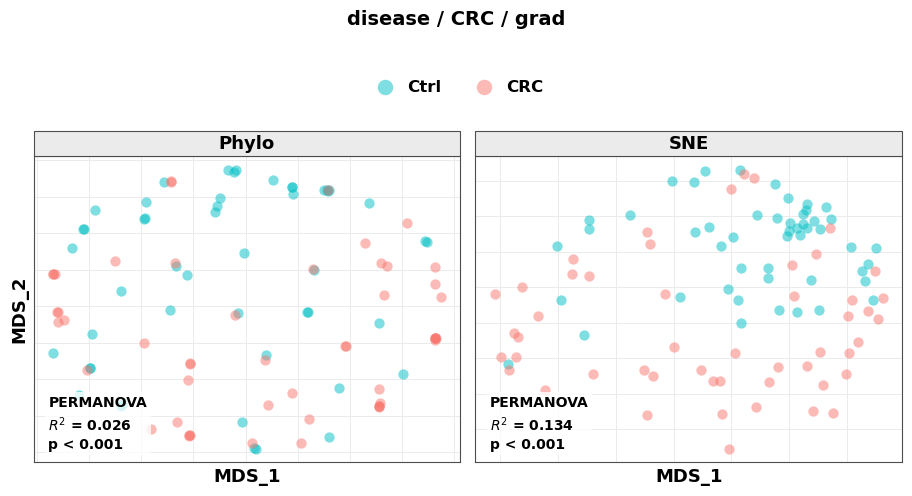

,task,disease,source,emb_type,pseudo_F,R2,p
0,disease,CRC,grad,Phylo,2.629146,0.026127,0.001
1,disease,CRC,grad,SNE,15.177104,0.134100,0.001


In [40]:
def plot_mds(task, disease, source, height=4.2, n_perm=N_PERM,
             save=None, dpi=200):
    """One panel per embedding, PERMANOVA annotated, theme_bw-ish."""
    path = os.path.join(OUT_DIR, f"MDS_{task}_{disease}_{source}.csv")
    d = pd.read_csv(path, index_col=0)

    facets = [e for e in ("Phylo", "SNE") if e in set(d.emb_type)]
    # Control first, whatever the disease is called, so the colours mean the
    # same thing in every figure.
    labels = ["Ctrl"] + [g for g in dict.fromkeys(d.group) if g != "Ctrl"]
    colors = dict(zip(labels, GROUP_COLORS))

    fig, axes = plt.subplots(1, len(facets),
                             figsize=(height * 1.05 * len(facets) + 0.4, height))
    axes = np.atleast_1d(axes)
    stats = []

    for ax, emb_type in zip(axes, facets):
        part = d[d.emb_type == emb_type]
        st = permanova(cosine_distances_for(emb_type, part.fid.tolist()),
                       part.group.to_numpy(), n_perm)
        stats.append(dict(task=task, disease=disease, source=source,
                          emb_type=emb_type, **st))

        for g in labels:
            s = part[part.group == g]
            ax.scatter(s.t_SNE_1, s.t_SNE_2, s=55, alpha=0.5, linewidths=0,
                       color=colors[g], label=g)

        # theme_bw: white panel, grey frame, faint grid, no ticks or tick text
        ax.set_facecolor("white")
        ax.grid(True, color="#EBEBEB", linewidth=0.7)
        ax.set_axisbelow(True)
        for sp in ax.spines.values():
            sp.set_color("#4D4D4D")
            sp.set_linewidth(0.8)
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)
        ax.set_xlabel("MDS_1", fontsize=13, fontweight="bold")
        if ax is axes[0]:
            ax.set_ylabel("MDS_2", fontsize=13, fontweight="bold")

        # facet strip, spanning the panel as ggplot's does rather than only
        # the width of its own text
        ax.add_patch(plt.Rectangle((0, 1.0), 1, 0.08, transform=ax.transAxes,
                                   facecolor="#EBEBEB", edgecolor="#4D4D4D",
                                   linewidth=0.8, clip_on=False, zorder=3))
        ax.text(0.5, 1.04, emb_type, transform=ax.transAxes, zorder=4,
                ha="center", va="center", fontsize=13, fontweight="bold")

        p_txt = ("p < 0.001" if st["p"] <= 1 / (n_perm + 1)
                 else f"p = {st['p']:.3f}")
        ax.text(0.035, 0.035,
                f"PERMANOVA\n$R^2$ = {st['R2']:.3f}\n{p_txt}",
                transform=ax.transAxes, ha="left", va="bottom",
                fontsize=10, fontweight="bold", linespacing=1.35,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none",
                          pad=2.5))

    handles, lab = axes[0].get_legend_handles_labels()
    fig.legend(handles, lab, loc="upper center", ncol=len(lab), frameon=False,
               bbox_to_anchor=(0.5, 1.04), markerscale=1.5,
               prop={"weight": "bold", "size": 12}, columnspacing=1.6,
               handletextpad=0.3)
    fig.suptitle(f"{task} / {disease} / {source}", fontsize=14,
                 fontweight="bold", y=1.17)
    fig.tight_layout()
    if save:
        fig.savefig(save, dpi=dpi, bbox_inches="tight")
        print(f"[out ] {save}")
    return fig, pd.DataFrame(stats)


fig, stats_crc = plot_mds("disease", "CRC", "grad")
plt.show()
stats_crc

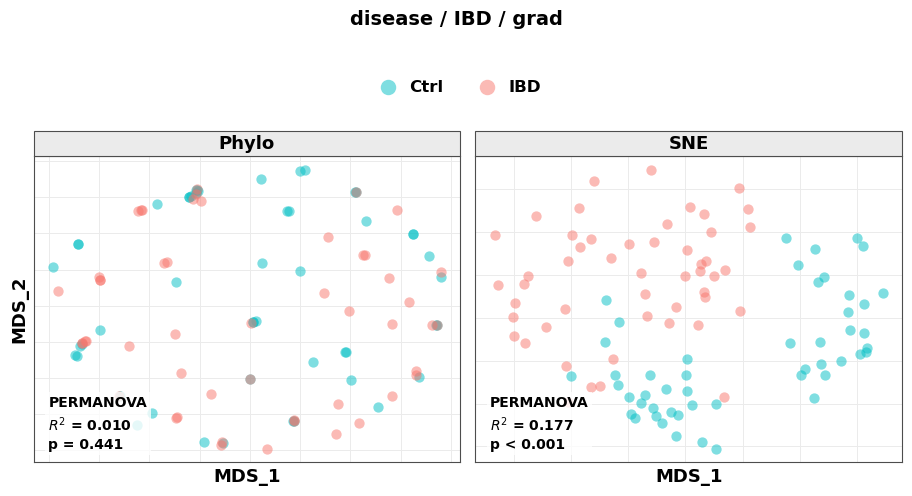

,task,disease,source,emb_type,pseudo_F,R2,p
0,disease,IBD,grad,Phylo,1.007716,0.010178,0.441
1,disease,IBD,grad,SNE,21.129389,0.177365,0.001


In [41]:
fig, stats_ibd = plot_mds("disease", "IBD", "grad")
plt.show()
stats_ibd

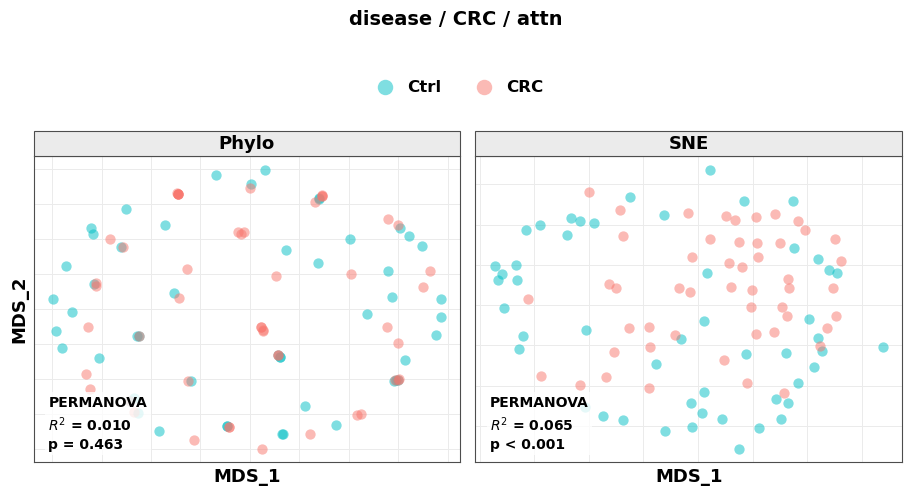

,task,disease,source,emb_type,pseudo_F,R2,p
0,disease,CRC,attn,Phylo,0.995155,0.010053,0.463
1,disease,CRC,attn,SNE,6.823417,0.065094,0.001


In [42]:
fig, stats_crc_attn = plot_mds("disease", "CRC", "attn")
plt.show()
stats_crc_attn

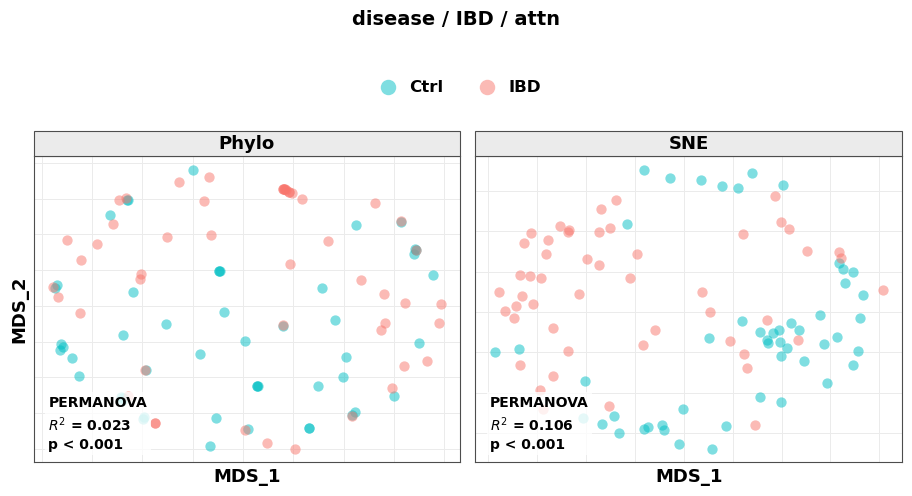

In [43]:
plot_mds("disease", "IBD", "attn")
plt.show()

## lodo pooled: every control marker against every disease marker

The section above contrasts control and disease markers **inside** each
left-out disease. This pools all thirteen into a single contrast: one taxon
ranking averaged over the diseases, its `TOP_N` most negative taxa as the
control group and its `TOP_N` most positive as the disease group, then the
same two embeddings and the same MDS.

Built from `shap_summary_lodo.csv` rather than from the thirteen per-fold
matrices. For `grad`, that file's `mean_signed` is already a fold's column
mean of the signed attributions, and for `attn` `case_minus_control` is
already the differential -- so averaging those over folds *is* the
fold-weighted pooling, and it reads one small file instead of a dozen large
ones.

A pooled ranking hides disagreement between diseases: a taxon that pushes
towards IBD and away from T2DM averages towards zero, which is the right
answer but an invisible one. `n_folds_same_sign` is carried alongside each
marker so that a taxon the pooled figure rests on can be checked -- 13/13
means every disease agreed, 7/13 means the pooled sign is barely a majority.

In [44]:
def pooled_importance(task, source):
    """Per-taxon signed value for every fold of a task, as a taxa x fold frame.

    Read from the summary file, not the per-fold matrices: `mean_signed` is
    already that fold's column mean of the signed attributions, and
    `case_minus_control` is already the attention differential.
    """
    prefix, col = (("attn", "case_minus_control") if source == "attn"
                   else ("shap", "mean_signed"))
    path = os.path.join(IN_DIR, f"{prefix}_summary_{task}.csv")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"{path} not found")
    wide = pd.read_csv(path).pivot_table(index="otu", columns="fold",
                                         values=col)
    # A taxon a fold never gave a non-zero attribution to is absent from that
    # fold's rows; it contributed nothing there, which is 0, not missing.
    return wide.reindex(taxa).fillna(0.0)


def pooled_contrast(task, source, top_n=TOP_N, write=True, label="Disease"):
    """One Control-vs-Disease contrast pooled over every fold of a task."""
    wide = pooled_importance(task, source)
    mean = wide.mean(axis=1)
    ctrl, dis = markers(mean, top_n)
    ids = list(ctrl) + list(dis)
    print(f"=== {task} / {source} pooled: {wide.shape[1]} fold(s), "
          f"{int((mean != 0).sum())} taxa with a non-zero pooled value ===")

    # How many folds actually agree with the sign the pooled mean settled on.
    sub = wide.loc[ids]
    nonzero = sub != 0
    agree = ((np.sign(sub) == np.sign(mean.loc[ids]).values[:, None])
             & nonzero).sum(axis=1)
    table = pd.DataFrame({
        "task": task, "source": source, "fid": ids,
        "group": ["Ctrl"] * len(ctrl) + [label] * len(dis),
        "importance": mean.loc[ids].values,
        "n_folds_nonzero": nonzero.sum(axis=1).values,
        "n_folds_same_sign": agree.values,
        "n_folds": wide.shape[1]})
    for g, part in table.groupby("group", sort=False):
        print(f"  [agree] {g:<8} median {part.n_folds_same_sign.median():.0f}"
              f"/{wide.shape[1]} folds share the pooled sign "
              f"(min {part.n_folds_same_sign.min():.0f})")

    frames, sep_rows = [], []
    for emb, emb_type in ((phylo, "Phylo"), (sne, "SNE")):
        frame, D, stress = mds_frame(emb, ctrl, dis, label, emb_type)
        sil, p = separation(D, ids, dis)
        frames.append(frame)
        sep_rows.append(dict(task=task, source=source, disease="pooled",
                             emb_type=emb_type, silhouette=sil, p_shuffle=p,
                             mds_stress=stress, n_markers=len(ids)))
        print(f"  [mds ] pooled {emb_type:<5} silhouette {sil:+.4f} "
              f"p={p:.3f}  stress {stress:.1f}")

    sep_df = pd.DataFrame(sep_rows)
    if write:
        path = os.path.join(OUT_DIR, f"MDS_{task}_pooled_{source}.csv")
        pd.concat(frames).to_csv(path)
        print(f"  [out ] {path}")
        table.to_csv(
            os.path.join(OUT_DIR, f"biomarkers_{task}_pooled_{source}.csv"),
            index=False)
        sep_df.to_csv(
            os.path.join(OUT_DIR, f"separation_{task}_pooled_{source}.csv"),
            index=False)
    return table, sep_df

In [45]:
markers_lodo_pooled, sep_lodo_pooled = pooled_contrast("lodo", "grad")

=== lodo / grad pooled: 13 fold(s), 7754 taxa with a non-zero pooled value ===
  [agree] Ctrl     median 11/13 folds share the pooled sign (min 6)
  [agree] Disease  median 10/13 folds share the pooled sign (min 4)
  [mds ] pooled Phylo silhouette +0.0034 p=0.158  stress 747.7
  [mds ] pooled SNE   silhouette +0.1357 p=0.001  stress 226.3
  [out ] Data/biomark/MDS_lodo_pooled_grad.csv


In [46]:
sep_lodo_pooled

,task,source,disease,emb_type,silhouette,p_shuffle,mds_stress,n_markers
0,lodo,grad,pooled,Phylo,0.003433,0.158,747.688137,100
1,lodo,grad,pooled,SNE,0.135655,0.001,226.276245,100


In [47]:
# The markers the pooled figure rests on, most consistent first
markers_lodo_pooled.sort_values(
    ["group", "n_folds_same_sign"], ascending=[True, False]).head(15)

,task,source,fid,group,importance,n_folds_nonzero,n_folds_same_sign,n_folds
2,lodo,grad,FJ362935.1.1246,Ctrl,-0.002794,13,13,13
5,lodo,grad,LARF01000109.1.1225,Ctrl,-0.002481,13,13,13
6,lodo,grad,ABQC02000019.758957.760260,Ctrl,-0.002456,13,13,13
16,lodo,grad,GQ133046.1.1200,Ctrl,-0.001868,13,13,13
19,lodo,grad,HQ808998.1.1217,Ctrl,-0.001852,13,13,13
26,lodo,grad,DQ809069.1.1219,Ctrl,-0.001589,13,13,13
32,lodo,grad,ABIY02000114.1.1263,Ctrl,-0.001367,13,13,13
33,lodo,grad,AY850463.1.1224,Ctrl,-0.001340,13,13,13
47,lodo,grad,FJ371591.1.1208,Ctrl,-0.001038,13,13,13
0,lodo,grad,DQ809255.1.1206,Ctrl,-0.004659,12,12,13


[out ] Data/biomark/MDS_lodo_pooled_grad.pdf


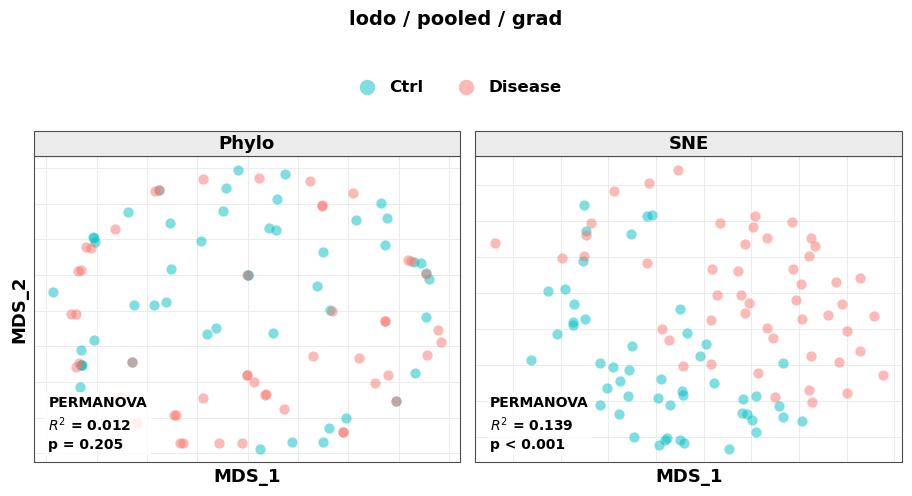

,task,disease,source,emb_type,pseudo_F,R2,p
0,lodo,pooled,grad,Phylo,1.170871,0.011807,0.205
1,lodo,pooled,grad,SNE,15.777294,0.138668,0.001


In [48]:
fig, stats_pooled = plot_mds("lodo", "pooled", "grad",
                             save=os.path.join(OUT_DIR, "MDS_lodo_pooled_grad.pdf"))
plt.show()
stats_pooled

The attention version of the same pooled contrast, for comparison.

=== lodo / attn pooled: 13 fold(s), 8592 taxa with a non-zero pooled value ===
  [agree] Ctrl     median 7/13 folds share the pooled sign (min 1)
  [agree] Disease  median 6/13 folds share the pooled sign (min 1)
  [mds ] pooled Phylo silhouette +0.0250 p=0.001  stress 740.8
  [mds ] pooled SNE   silhouette +0.1186 p=0.001  stress 365.2
  [out ] Data/biomark/MDS_lodo_pooled_attn.csv


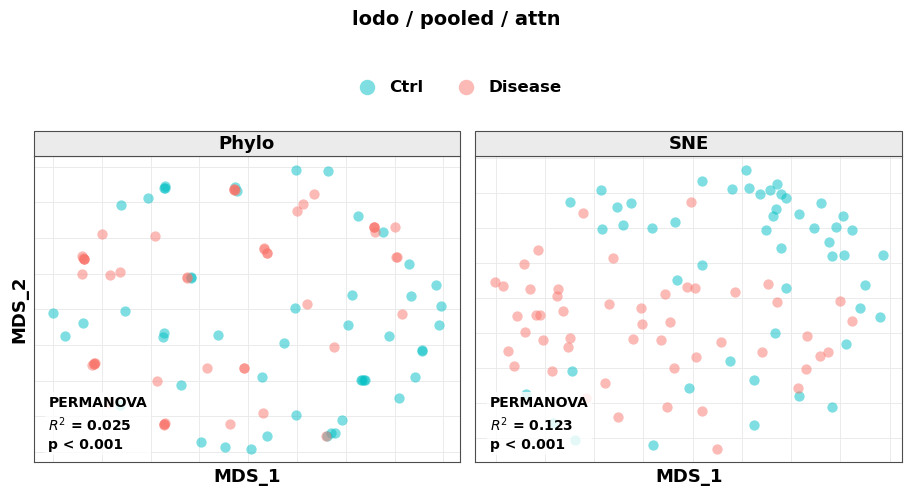

,task,disease,source,emb_type,pseudo_F,R2,p
0,lodo,pooled,attn,Phylo,2.481399,0.024695,0.001
1,lodo,pooled,attn,SNE,13.703456,0.122677,0.001


In [49]:
markers_lodo_pooled_attn, sep_lodo_pooled_attn = pooled_contrast("lodo", "attn")
fig, stats_pooled_attn = plot_mds("lodo", "pooled", "attn")
plt.show()
stats_pooled_attn

## Are the biomarker taxa the ones the model actually attends to?

The IBD and CRC marker lists below come from **LinDA** differential
abundance testing on the raw counts (`linda_res_study.csv`, one row per
study x taxon) -- not from this model, unlike the gradient-based
`markers_dis` used earlier in this notebook. This asks: do the taxa an
independent statistical test calls disease- or control-associated also
receive more **attention** than the rest? Three groups: LinDA
control-associated taxa, LinDA disease-associated taxa, and every other
taxon.

Nothing needs re-running. The old code took
`torch.mean(attention_weight[:, 0], axis=1)` -- the mean over the query axis of
head 0, i.e. how much the community as a whole attends to each key position --
and that is exactly what `explain_attention.py` already computed and stored.
`attn_summary_{task}.csv` holds it per fold per taxon in the `enrichment`
column, normalised by the sample's taxon count so that `1.0` means "attended
as much as an average taxon of that sample". The old figure's raw attention
share is this divided by `n_valid`, which is why its axis sat near 1e-3 with
`num_steps = 600`: uniform attention is `1/600 = 1.7e-3`.

Two things to keep in mind when reading it:

* **The pooled lodo panel below is not this comparison.** It still uses the
  gradient-based `markers_lodo_pooled` -- no per-disease LinDA call exists
  pooled over all thirteen diseases -- so there the gradient and the
  attention remain two read-outs of the same network, and some agreement is
  expected rather than discovered.
* **Non-biomarkers are restricted to taxa that could have been markers** --
  those the two embeddings both cover. A taxon outside that set was never a
  candidate and counting it as a negative would flatter the contrast.

The colours below are the ones from the earlier bar chart, where control is
salmon and the disease is teal. That is the **reverse** of the MDS panels
above. Pass `palette=MDS_PALETTE` to make the two figures agree, or leave it
to match the previously published version -- but do not ship both as they
are.

In [5]:
from scipy.stats import kruskal, mannwhitneyu
GROUP_COLORS = ("#00BFC4", "#F8766D")   # control, disease
# The palette of the earlier bar chart, and the one the MDS panels use. They
# disagree about which group is which colour; see the note above.
BAR_PALETTE = {"Ctrl": "#F9938B", "Disease": "#3FCFD2",
               "Non-Biomarker": "#B0B0B0"}
MDS_PALETTE = {"Ctrl": GROUP_COLORS[0], "Disease": GROUP_COLORS[1],
               "Non-Biomarker": "#B0B0B0"}


def attention_by_group(task, disease, marker_table, label="Disease"):
    """Mean attention enrichment per taxon, tagged by its biomarker group.

    `marker_table` is a frame with `fid` and `group` columns -- either one
    disease's slice of `markers_dis` or the pooled `markers_lodo_pooled`.
    `disease="pooled"` uses every fold of the task.
    """
    s = pd.read_csv(os.path.join(IN_DIR, f"attn_summary_{task}.csv"))
    if disease != "pooled":
        s = s[s.disease == disease]
    if s.empty:
        raise ValueError(f"no attention rows for {task}/{disease}")
    wide = s.pivot_table(index="otu", columns="fold", values="enrichment")
    mean = wide.mean(axis=1)

    # Only taxa that could have been markers count as negatives.
    mean = mean[mean.index.isin(taxa)]

    ctrl = set(marker_table.loc[marker_table.group == "Ctrl", "fid"])
    dis = set(marker_table.loc[marker_table.group != "Ctrl", "fid"])
    grp = np.where(mean.index.isin(ctrl), "Ctrl",
                   np.where(mean.index.isin(dis), label, "Non-Biomarker"))
    out = pd.DataFrame({"otu": mean.index, "attention_weight": mean.values,
                        "group1": grp})
    print(f"{task}/{disease}: {wide.shape[1]} fold(s), "
          + ", ".join(f"{g} n={int(n)}"
                      for g, n in out.group1.value_counts().items()))
    return out

In [12]:
LINDA_DIR = "Data/IBD_CRC_model"   # per-disease linda_res_study.csv, as in IBD_CRC_datasize_attention.ipynb

# Same thresholds that notebook applies to the same file.
LINDA_THRESH = {"IBD": (-1, 0.8), "CRC": (-0.8, 0.8)}


def linda_markers(disease, ctrl_thresh, dis_thresh):
    """Ctrl/disease taxa from LinDA differential abundance testing.

    Independent of the model -- unlike `markers_dis`, which comes from this
    model's own gradient. One row per study x taxon; only tests LinDA called
    significant (`reject == True`) count, averaged per taxon over studies,
    then split on the log2FoldChange thresholds IBD_CRC_datasize_attention.py
    uses for this same file.
    """
    path = os.path.join(LINDA_DIR, disease, "linda_res_study.csv")
    df = pd.read_csv(path)
    sig = df.loc[df.reject == True]
    mean_l2fc = sig.loc[:, ["fid", "log2FoldChange"]].groupby("fid").mean()
    ctrl = [str(i) for i in mean_l2fc.loc[mean_l2fc.log2FoldChange < ctrl_thresh].index]
    dis = [str(i) for i in mean_l2fc.loc[mean_l2fc.log2FoldChange > dis_thresh].index]
    print(f"{disease}: {len(sig)} significant tests, {len(ctrl)} control-enriched, "
          f"{len(dis)} {disease}-enriched taxa "
          f"(LinDA, log2FC < {ctrl_thresh} / > {dis_thresh})")
    return pd.DataFrame({"fid": ctrl + dis,
                         "group": ["Ctrl"] * len(ctrl) + [disease] * len(dis)})

In [13]:
def plot_attention_bars(df, label="Disease", palette=BAR_PALETTE,
                        ylabel="Average attention enrichment",
                        figsize=(4.2, 4.4), ylim=None, sci=False,
                        reference=1.0, save=None, dpi=300):
    """The three-group bar chart, with the tests the comparison needs.

    Kruskal-Wallis across the three groups, then Mann-Whitney U for each
    marker group against the non-markers. Non-parametric because these are
    per-taxon means over a heavily skewed distribution, not draws from
    anything normal.
    """
    order = ["Ctrl", label, "Non-Biomarker"]
    colors = {**palette}
    colors.setdefault(label, palette.get("Disease", "#3FCFD2"))
    vals = {g: df.loc[df.group1 == g, "attention_weight"].to_numpy()
            for g in order}
    vals = {g: v for g, v in vals.items() if len(v)}
    order = [g for g in order if g in vals]

    kw = kruskal(*vals.values()) if len(order) > 2 else None
    tests = []
    for g in order:
        if g == "Non-Biomarker" or "Non-Biomarker" not in vals:
            continue
        u, p = mannwhitneyu(vals[g], vals["Non-Biomarker"],
                            alternative="two-sided")
        tests.append(dict(group=g, vs="Non-Biomarker", U=float(u), p=float(p),
                          n=len(vals[g]), n_ref=len(vals["Non-Biomarker"]),
                          mean=float(vals[g].mean()),
                          mean_ref=float(vals["Non-Biomarker"].mean())))

    with sns.axes_style("ticks"):
        fig, ax = plt.subplots(figsize=figsize)
        pos = [0, 0.3, 0.6][:len(order)]
        heights = [vals[g].mean() for g in order]
        errs = [vals[g].std(ddof=1) / np.sqrt(len(vals[g])) for g in order]
        ax.bar(pos, heights, width=0.2, color=[colors[g] for g in order],
               yerr=errs, capsize=3, error_kw=dict(elinewidth=1.1))

        if reference is not None:
            ax.axhline(reference, color="#4D4D4D", linestyle="--",
                       linewidth=0.9, zorder=0)

        top = max(h + e for h, e in zip(heights, errs))
        step = top * 0.09
        for k, t in enumerate(tests):
            i, j = order.index(t["group"]), order.index("Non-Biomarker")
            y = top + step * (k + 1)
            ax.plot([pos[i], pos[i], pos[j], pos[j]],
                    [y - step * 0.22, y, y, y - step * 0.22],
                    color="black", linewidth=1.0)
            star = ("p < 1e-4" if t["p"] < 1e-4 else f"p = {t['p']:.3g}")
            ax.text((pos[i] + pos[j]) / 2, y + step * 0.06, star,
                    ha="center", va="bottom", fontsize=10)

        if sci:
            ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
        ax.set_ylabel(ylabel, fontsize=13)
        ax.set_xlabel("")
        ax.set_xticks(pos)
        ax.set_xticklabels(order, fontsize=13, rotation=20, ha="right")
        ax.set_ylim(0 if ylim is None else ylim[0],
                    (top + step * (len(tests) + 1.4)) if ylim is None
                    else ylim[1])
        if kw is not None:
            ax.set_title(f"Kruskal-Wallis p = {kw.pvalue:.3g}", fontsize=11)
        sns.despine(ax=ax)
        fig.tight_layout()
        if save:
            fig.savefig(save, dpi=dpi, bbox_inches="tight")
            print(f"[out ] {save}")
    return fig, pd.DataFrame(tests)

IBD: 1114 significant tests, 151 control-enriched, 92 IBD-enriched taxa (LinDA, log2FC < -1 / > 0.8)
disease/IBD: 8 fold(s), Non-Biomarker n=4059, Ctrl n=151, IBD n=92
[out ] Data/biomark/attention_weights_IBD.png


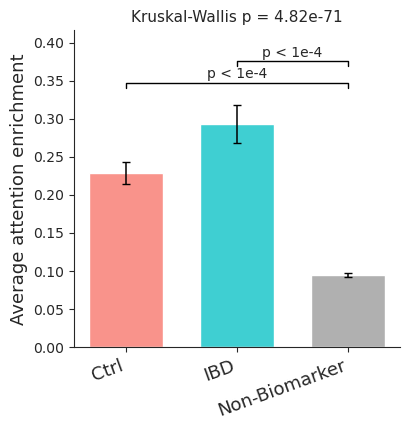

,group,vs,U,p,n,n_ref,mean,mean_ref
0,Ctrl,Non-Biomarker,509919.0,9.162821e-44,151,4059,0.229033,0.095015
1,IBD,Non-Biomarker,321323.0,2.362824e-32,92,4059,0.293564,0.095015


In [14]:
# IBD, markers from LinDA differential abundance, attention from this model
attn_ibd = attention_by_group("disease", "IBD",
                              linda_markers("IBD", *LINDA_THRESH["IBD"]),
                              label="IBD")
fig, tests_ibd = plot_attention_bars(
    attn_ibd, label="IBD",
    save=os.path.join(OUT_DIR, "attention_weights_IBD.png"))
plt.show()
tests_ibd

CRC: 342 significant tests, 56 control-enriched, 65 CRC-enriched taxa (LinDA, log2FC < -0.8 / > 0.8)
disease/CRC: 7 fold(s), Non-Biomarker n=1748, CRC n=52, Ctrl n=52
[out ] Data/biomark/attention_weights_CRC.png


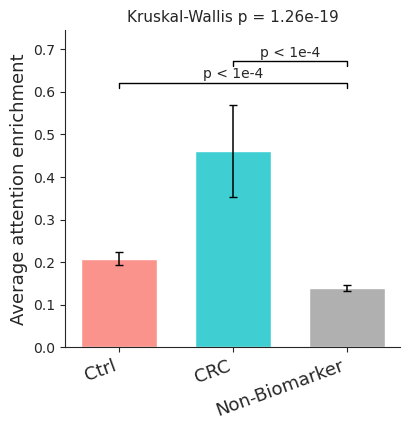

,group,vs,U,p,n,n_ref,mean,mean_ref
0,Ctrl,Non-Biomarker,67693.0,1.716371e-09,52,1748,0.208089,0.139027
1,CRC,Non-Biomarker,72356.0,3.214633e-13,52,1748,0.461323,0.139027


In [15]:
# CRC, markers from LinDA differential abundance, attention from this model
attn_crc = attention_by_group("disease", "CRC",
                              linda_markers("CRC", *LINDA_THRESH["CRC"]),
                              label="CRC")
fig, tests_crc = plot_attention_bars(
    attn_crc, label="CRC",
    save=os.path.join(OUT_DIR, "attention_weights_CRC.png"))
plt.show()
tests_crc

lodo/pooled: 13 fold(s), Non-Biomarker n=8492, Ctrl n=50, Disease n=50
[out ] Data/biomark/attention_weights_lodo_pooled.png


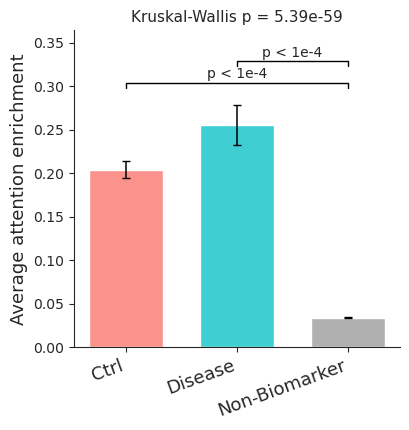

,group,vs,U,p,n,n_ref,mean,mean_ref
0,Ctrl,Non-Biomarker,413900.0,4.349459e-31,50,8492,0.204041,0.034057
1,Disease,Non-Biomarker,414648.0,2.629022e-31,50,8492,0.255602,0.034057


In [54]:
# lodo, pooled over all thirteen left-out diseases
attn_lodo = attention_by_group("lodo", "pooled", markers_lodo_pooled)
fig, tests_lodo = plot_attention_bars(
    attn_lodo, save=os.path.join(OUT_DIR, "attention_weights_lodo_pooled.png"))
plt.show()
tests_lodo

## Pooled representation heatmap

One row per held-out sample, one column per pooling dimension: the vector the
output head actually reads. In the forward pass that is the mean, over a
sample's unmasked taxa, of the encoder stack's output -- so **after** the
attention and the feed-forward sub-layer -- which is the `d_model = 100`
representation the classifier sees.

`explain_attention.py` writes it with `--dump-pooled`, meaned over the fold's
members, with the sample's label in the first column. Nothing needs the
integration, so pair it with `--skip-ig` and the run takes minutes:

    python explain_attention.py --task disease --run-name results_with_SNEs_ckpt \
        --run-tsv run_leave_one_study_out_explain.tsv --diseases CRC IBD \
        --gpus 0 1 2 3 4 5 6 7 --dump-pooled --skip-ig

A disease's rows come from several folds, one per held-out cohort, so every
sample appears exactly once -- represented by the ensemble that never trained
on its cohort. Rows and columns are then reordered by hierarchical clustering,
as in the earlier version of this figure.

Two knobs worth knowing. `standardize="col"` z-scores each dimension before
plotting; the reference version did not, and a single dimension with a much
larger scale can otherwise flatten the rest of the map. And the rows carry a
cohort as well as a label -- if the clustering splits by fold rather than by
group, what the picture shows is a batch effect, so `row_split` prints the
composition of the two top-level clusters to make that visible rather than
decorative.

In [58]:
def load_pooled(task, disease):
    """Pooled encoder output for every held-out sample of a disease.

    One file per fold, concatenated: a sample belongs to exactly one held-out
    cohort, so no row appears twice.
    """
    fl = fold_table(task, "grad")
    parts = []
    for fold, d in sorted(fl.items()):
        if disease != "pooled" and d != disease:
            continue
        path = os.path.join(IN_DIR, f"pool_{task}_{fold}.csv")
        if not os.path.isfile(path):
            print(f"  [skip] {path} not found -- run with --dump-pooled")
            continue
        df = pd.read_csv(path, index_col=0)
        parts.append(pd.concat(
            [pd.Series(fold, index=df.index, name="fold"), df], axis=1))
    if not parts:
        raise FileNotFoundError(
            f"no pool_{task}_* files for {disease}; run explain_attention.py "
            f"with --dump-pooled --skip-ig")
    out = pd.concat(parts)
    dims = [c for c in out.columns if c.startswith("dim_")]
    print(f"{task}/{disease}: {out.shape[0]} samples x {len(dims)} dims "
          f"from {out.fold.nunique()} fold(s); "
          f"labels {out.label.value_counts().to_dict()}")
    return out


def cluster_and_reorder(M, labels=None, extra=None, cluster_rows=True,
                        cluster_cols=True, method="average",
                        metric="euclidean"):
    """Hierarchical reordering of a matrix's rows and columns."""
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist

    M = np.asarray(M, dtype=float)
    row_link, order = None, np.arange(M.shape[0])
    if cluster_rows and M.shape[0] > 1:
        row_link = linkage(pdist(M, metric=metric), method=method)
        order = leaves_list(row_link)
        M = M[order, :]
        labels = None if labels is None else np.asarray(labels)[order]
        extra = None if extra is None else np.asarray(extra)[order]
    if cluster_cols and M.shape[1] > 1:
        col_link = linkage(pdist(M.T, metric=metric), method=method)
        M = M[:, leaves_list(col_link)]
    # `order` is returned because a linkage is built on the *original* row
    # order: anything read off it later, fcluster included, comes back in that
    # order and has to be permuted the same way the rows were.
    return M, labels, extra, row_link, order

In [59]:
def plot_pooled_heatmap(task, disease, group_info=None, colormap="RdBu_r",
                        figsize=(6.4, 4.4), standardize=None, row_split=True,
                        save=None, dpi=150, title=None):
    """Samples x pooling dimensions, clustered, with a group strip on the left."""
    import matplotlib.gridspec as gridspec
    from matplotlib.colors import ListedColormap, Normalize
    from matplotlib.patches import Patch
    from scipy.cluster.hierarchy import fcluster

    group_info = group_info or {"Ctrl": "#F9938B", "Case": "#3FCFD2"}
    df = load_pooled(task, disease)
    dims = [c for c in df.columns if c.startswith("dim_")]
    M = df[dims].to_numpy(dtype=float)
    if standardize == "col":
        M = (M - M.mean(0)) / np.clip(M.std(0, ddof=0), 1e-12, None)
    elif standardize == "row":
        M = (M - M.mean(1, keepdims=True)) / np.clip(
            M.std(1, keepdims=True, ddof=0), 1e-12, None)

    M, lab, folds, row_link, order = cluster_and_reorder(
        M, df.label.to_numpy(), df.fold.to_numpy())

    # Does the top-level split follow the label, or the cohort? A heatmap that
    # separates by fold is a picture of a batch effect.
    if row_split and row_link is not None and M.shape[0] > 2:
        cl = fcluster(row_link, 2, criterion="maxclust")[order]
        for c in (1, 2):
            m = cl == c
            if m.sum():
                top = pd.Series(folds[m]).value_counts().head(2).to_dict()
                print(f"  [split] cluster {c}: n={int(m.sum())}, "
                      f"cases {int((lab[m] == 1).sum())}/{int(m.sum())}, "
                      f"largest folds {top}")

    fig = plt.figure(figsize=figsize, dpi=dpi)
    vmax = np.nanmax(np.abs(M))
    norm = Normalize(vmin=-vmax, vmax=vmax)
    names = list(group_info)
    label_cmap = ListedColormap([group_info[n] for n in names])

    main = gridspec.GridSpec(1, 2, width_ratios=[1, 0.3], wspace=0.10,
                             figure=fig)
    left = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=main[0],
                                            width_ratios=[0.07, 1], wspace=0.05)
    ax_lab = fig.add_subplot(left[0])
    ax_hm = fig.add_subplot(left[1])

    ax_lab.imshow(lab.reshape(-1, 1), aspect="auto", cmap=label_cmap,
                  vmin=0, vmax=len(names) - 1, interpolation="nearest")
    ax_lab.set_ylabel("Samples", fontsize=18)
    ax_lab.set_xticks([]); ax_lab.set_yticks([])

    im = ax_hm.imshow(M, aspect="auto", cmap=colormap, norm=norm,
                      interpolation="nearest")
    ax_hm.set_xlabel("Attention Pooling", fontsize=18)
    ax_hm.set_xticks([]); ax_hm.set_yticks([])

    right = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=main[1],
                                             height_ratios=[1, 2], hspace=0.3)
    ax_leg = fig.add_subplot(right[0])
    ax_leg.axis("off")
    ax_leg.legend(handles=[Patch(facecolor=group_info[n], label=n,
                                 edgecolor="black") for n in names],
                  title="Group", loc="center left", frameon=False,
                  fontsize=10, title_fontsize=12, labelspacing=0.8)

    cbar_cell = gridspec.GridSpecFromSubplotSpec(
        1, 3, subplot_spec=right[1], width_ratios=[0.2, 0.2, 0.6], wspace=0.1)
    cbar = fig.colorbar(im, cax=fig.add_subplot(cbar_cell[0, 1]))
    cbar.ax.set_title("Value", fontsize=12, pad=10)
    cbar.ax.tick_params(labelsize=10)

    # Centre the title over the strip plus heatmap rather than over the figure,
    # which the legend column would otherwise pull it off.
    fig.canvas.draw()
    x = (ax_lab.get_position().x0 + ax_hm.get_position().x1) / 2
    fig.suptitle(title or disease, fontsize=20, x=x)
    fig.subplots_adjust(top=0.88)

    if save:
        fig.savefig(save, bbox_inches="tight", dpi=dpi)
        print(f"  [out ] {save}")
    return fig, df

disease/IBD: 2514 samples x 100 dims from 8 fold(s); labels {1: 1866, 0: 648}
  [split] cluster 1: n=64, cases 33/64, largest folds {'IBD_PRJNA368966': 64}
  [split] cluster 2: n=2450, cases 1833/2450, largest folds {'IBD_qiita_2538': 709, 'IBD_qiita_1629': 552}
  [out ] Data/biomark/IBD_pooled_heatmap.png


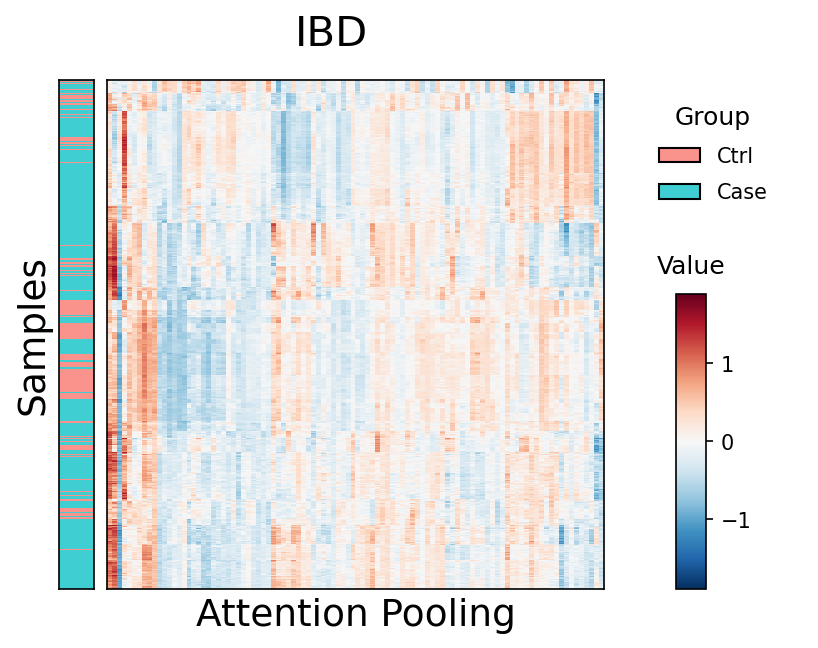

In [60]:
fig, pooled_ibd = plot_pooled_heatmap(
    "disease", "IBD",
    save=os.path.join(OUT_DIR, "IBD_pooled_heatmap.png"))
plt.show()

disease/CRC: 1034 samples x 100 dims from 7 fold(s); labels {0: 614, 1: 420}
  [split] cluster 1: n=1033, cases 420/1033, largest folds {'CRC_PRJNA290926': 255, 'CRC_PRJNA318004': 228}
  [split] cluster 2: n=1, cases 0/1, largest folds {'CRC_PRJNA824020': 1}
  [out ] Data/biomark/CRC_pooled_heatmap.png


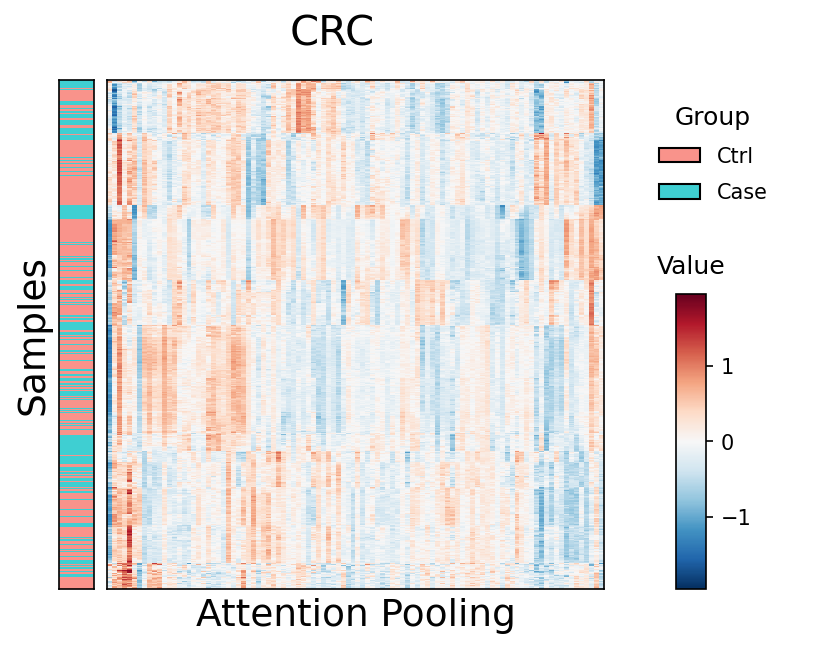

In [61]:
fig, pooled_crc = plot_pooled_heatmap(
    "disease", "CRC",
    save=os.path.join(OUT_DIR, "CRC_pooled_heatmap.png"))
plt.show()

disease/IBD: 2514 samples x 100 dims from 8 fold(s); labels {1: 1866, 0: 648}
  [split] cluster 1: n=64, cases 33/64, largest folds {'IBD_PRJNA368966': 64}
  [split] cluster 2: n=2450, cases 1833/2450, largest folds {'IBD_qiita_2538': 709, 'IBD_qiita_1629': 552}


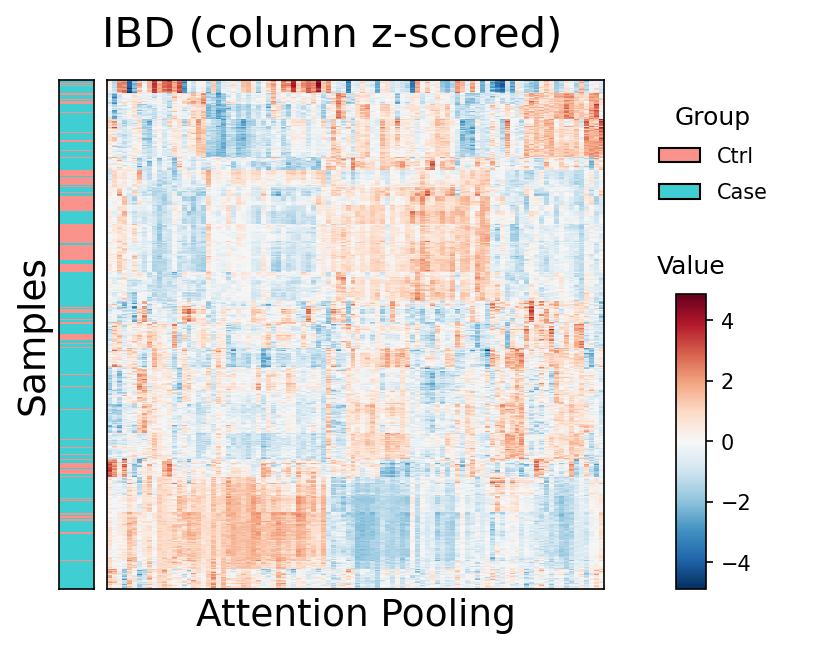

In [62]:
# Per-dimension z-scores, when one dimension's scale flattens the rest
fig, _ = plot_pooled_heatmap("disease", "IBD", standardize="col",
                             title="IBD (column z-scored)")
plt.show()